# 02 · Forecasting: protocol, results, error analysis
All numbers are read from `artifacts/metrics.json` (written by `python -m taxidemand.train`, tracked in MLflow).

**Framing.** Direct multi-horizon forecasting: a row is *(forecast origin t, zone, horizon h = 1…24)*. Features known at t: lags, rolling means, city-wide demand, and *how unusual the current hour is versus its 4-week same-hour average*. Known for the target hour: clock, holiday flags and weather (in production: the weather forecast).
**Target:** `log1p(y) − log1p(4-week average)`; **models:** one LightGBM per horizon bucket (1-3, 4-6, 7-12, 13-24 h) shared by the 150 modelled zones (99.05% of trips).

**Protocol (time-ordered):** train Jan-May · validation June (hyper-parameter search, metric MAPE) · **test July (scored once)** · stress test on 4 blizzard days held out of training.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import pandas as pd
from IPython.display import Image
from taxidemand import config as C
m = json.loads((C.ARTIFACTS_DIR / "metrics.json").read_text())
print(m["data"]); print(m["search"]["best_params"])
pd.DataFrame(m["search"]["trials"])[["trial", "num_leaves", "min_child_samples", "n_estimators", "_objective", "valid_mape_pct", "valid_wape_pct"]].round(2)

{'hours': 5087, 'modelled_zones': 150, 'tail_zones': 110, 'modelled_trip_share_pct': 99.04699572797058, 'train_rows': 2948400, 'test_rows': 1339200, 'test_origins': 384, 'test_window': ['2026-07-01 00:00', '2026-07-31 23:00'], 'n_features': 56}
{'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 127, 'min_child_samples': 50, 'feature_fraction': 0.6, 'lambda_l2': 5.0, '_objective': 'l1'}


,trial,num_leaves,min_child_samples,n_estimators,_objective,valid_mape_pct,valid_wape_pct
0,0,63,100,400,regression,27.45,19.44
1,1,127,100,300,l1,27.25,19.16
2,2,127,50,300,l1,27.15,18.98
3,3,127,300,700,regression,27.20,19.20
4,4,63,100,700,l1,27.18,18.93
5,5,63,100,700,regression,27.35,19.31
6,6,31,50,500,regression,27.30,19.16


All 7 configurations score within 27.15-27.45% validation MAPE: hyper-parameters barely matter; the information in the features does.

### Test month (July 2026): overall

In [2]:
t = m["test"]
pd.DataFrame(t["overall"]).T[["mape_pct", "wape_pct", "rmse", "mae", "bias", "mape_coverage_pct"]].round(2)

,mape_pct,wape_pct,rmse,mae,bias,mape_coverage_pct
lightgbm,28.66,20.33,15.34,6.28,0.48,47.67
historical_avg_4wk,32.18,23.10,18.13,7.13,1.19,47.67
same_hour_last_week,37.10,26.64,20.72,8.23,0.08,47.67
same_hour_yesterday,44.47,30.33,24.41,9.37,-0.11,47.67


*MAPE is computed only where the actual count is ≥ 5 pickups (otherwise it is undefined / explosive); `mape_coverage_pct` says what share of zone-hours that is (~48%). WAPE = Σ|error| / Σ actual covers every cell.*

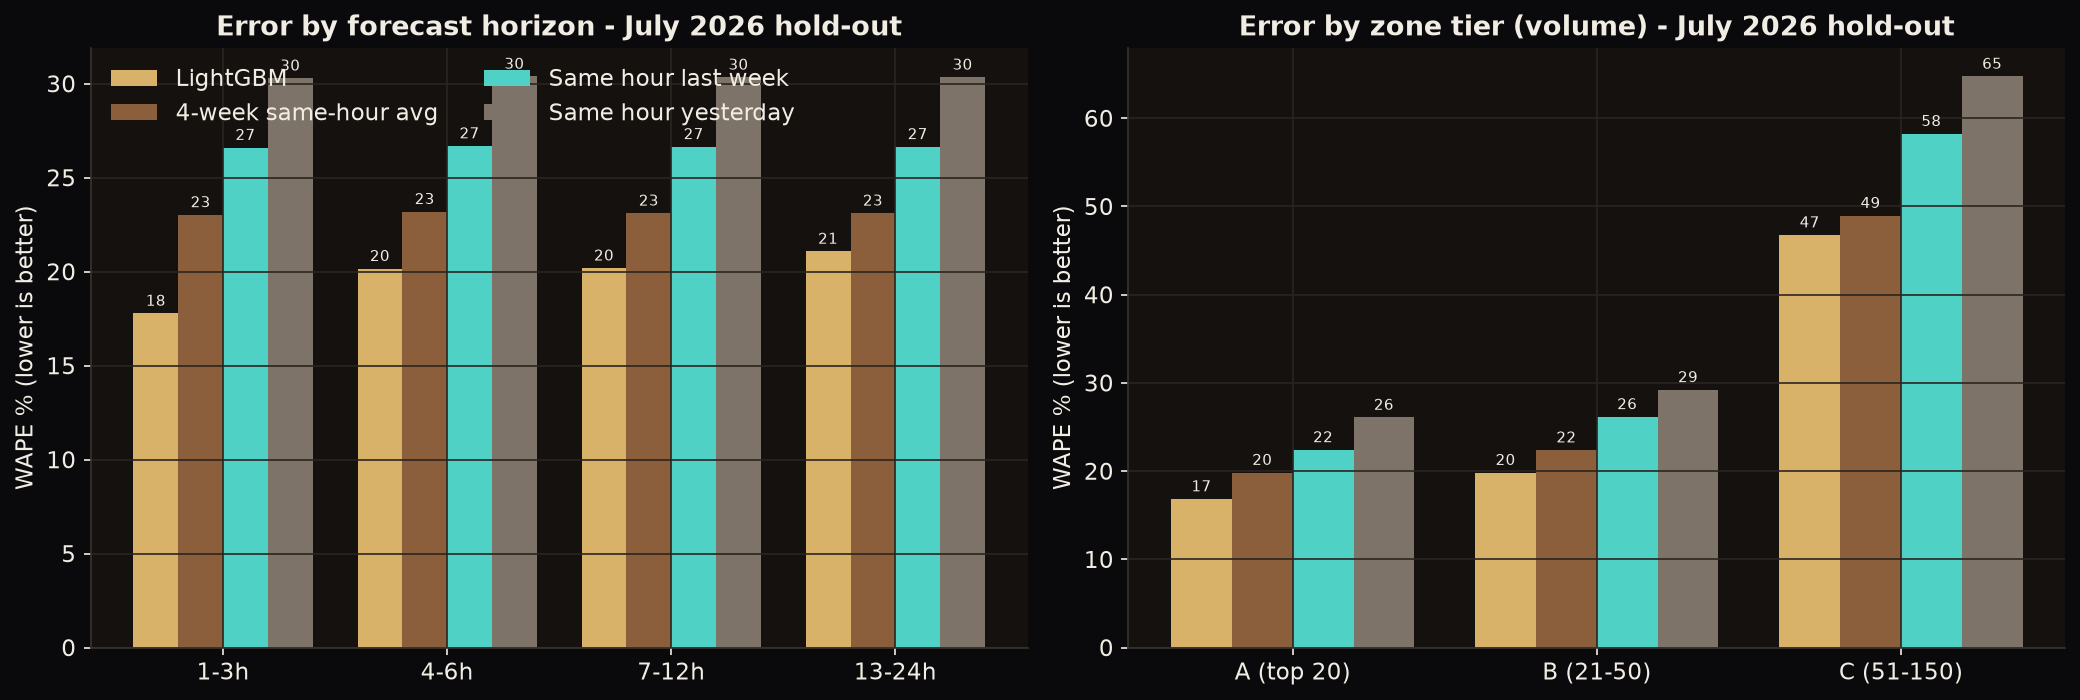

In [3]:
Image(str(C.FIGURES_DIR / "03_error_horizon_tier.png"))

In [4]:
for k in ("by_tier", "by_horizon"):
    df = pd.DataFrame({lab: {g: v["wape_pct"] for g, v in t[k][lab].items()} for lab in ("lightgbm", "historical_avg_4wk", "same_hour_last_week")})
    print(k, "(WAPE %)"); print(df.round(1).to_string(), "\n")
print("MAPE % by tier (cells >= 5):")
print(pd.DataFrame({lab: {g: v["mape_pct"] for g, v in t["by_tier"][lab].items()} for lab in ("lightgbm", "historical_avg_4wk")}).round(1))

by_tier (WAPE %)
            lightgbm  historical_avg_4wk  same_hour_last_week
A (top 20)      16.8                19.8                 22.4
B (21-50)       19.8                22.4                 26.1
C (51-150)      46.8                48.9                 58.2 

by_horizon (WAPE %)
        lightgbm  historical_avg_4wk  same_hour_last_week
1-3h        17.8                23.0                 26.6
4-6h        20.2                23.2                 26.7
7-12h       20.2                23.1                 26.6
13-24h      21.1                23.1                 26.6 

MAPE % by tier (cells >= 5):
            lightgbm  historical_avg_4wk
A (top 20)      22.5                27.6
B (21-50)       25.3                28.7
C (51-150)      37.5                39.8


**Reading it honestly**
* LightGBM beats the 4-week average at **every horizon**, but the gain is concentrated in the first 6 hours (17.8% vs 23.0% WAPE at 1-3 h) and shrinks later (21.1% vs 23.1% at 13-24 h). Hourly demand in a single zone is intrinsically noisy; beyond ~6 h the 4-week same-hour average is already near what is achievable.
* July was a *harder* month than June (the 4-week average scored 16-19% WAPE on the top-50 zones in June vs 20-22% in July) because it contains the Jul 3-4 holiday and a heavy-rain day.
* Tier-C zones (ranks 51-150, ~3 pickups/hour) are inherently unpredictable at zone-hour level (WAPE ~47%).

### Holidays, weather and time of day

In [5]:
cond = pd.DataFrame({lab: {c: (v["wape_pct"] if v else None) for c, v in t["by_condition"][lab].items()} for lab in ("lightgbm", "historical_avg_4wk", "same_hour_last_week")})
cond.round(1)

,lightgbm,historical_avg_4wk,same_hour_last_week
holiday,43.9,66.3,61.4
non_holiday,19.1,20.9,24.9
rain_(>=0.5mm/h),23.4,26.5,27.2
dry,19.8,22.5,26.5
weekend,25.0,29.0,36.3
weekday,18.8,21.1,23.4


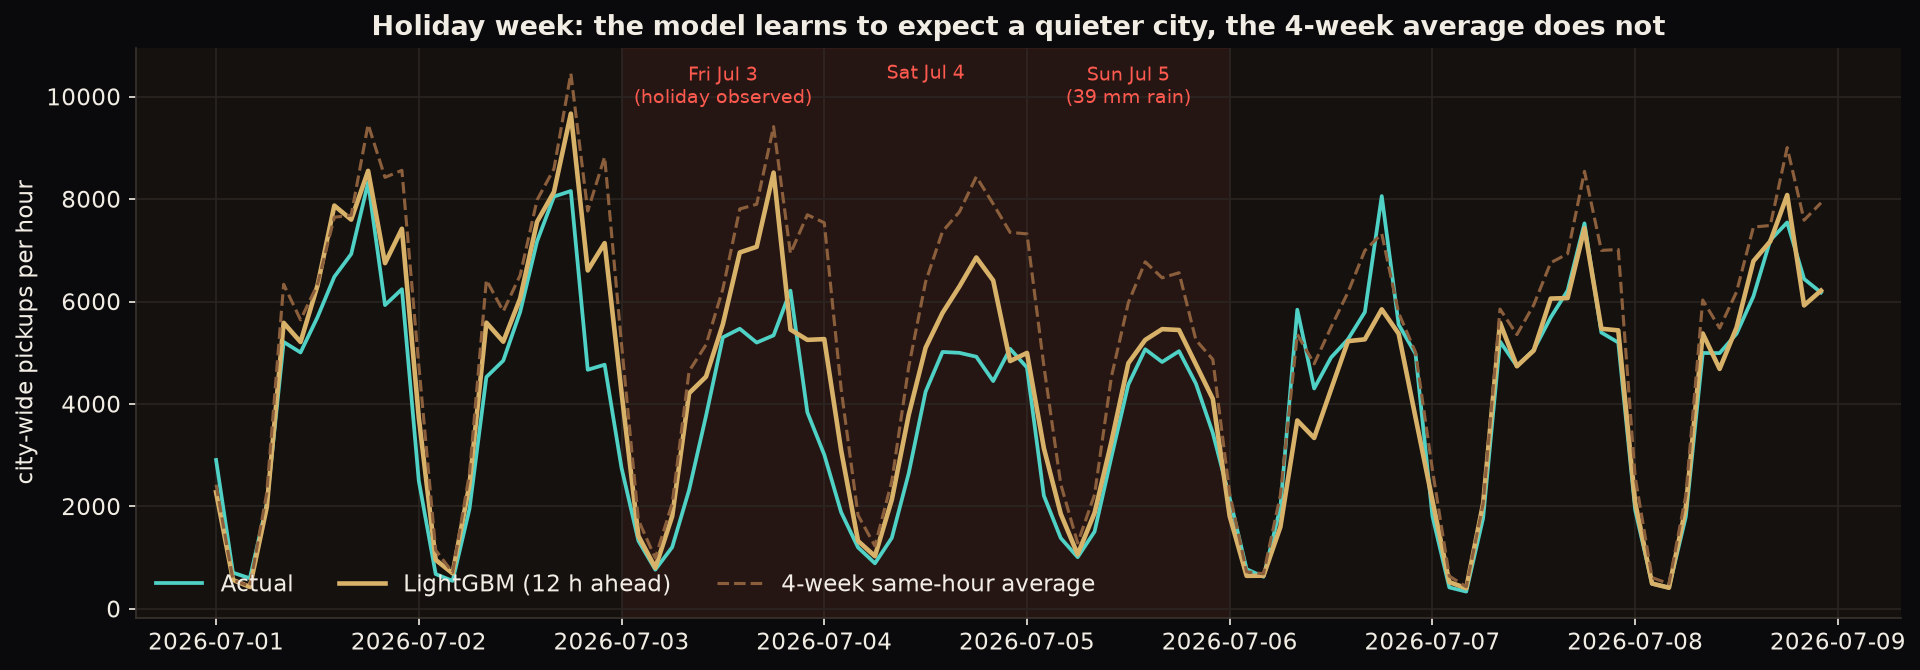

In [6]:
Image(str(C.FIGURES_DIR / "04_holiday_week.png"))

* **Holidays:** WAPE on the two July holiday days falls from 66% (4-week average) to **44%** with the model: it learned a "quieter city" pattern from Jan 1, MLK, Presidents' Day, Memorial Day and Juneteenth. It still over-forecasts the holiday-Friday evening peak (roughly 8,500 forecast vs 6,200 actual city-wide pickups per hour), so 44% is far from good.
* **Rain (≥ 0.5 mm/h):** WAPE 23.4% vs 19.8% dry - rain is harder to forecast, and in training the "forecast" weather is actually observed weather, which flatters the model.
* **Night hours** (1-4 am) have ~35-38% WAPE (tiny counts); the late morning is best (~16%).

### Blizzard stress test (4 storm days held out of training)

In [7]:
s = m["storm_stress_test"]
pd.Series({k: v["wape_pct"] for k, v in s.items() if isinstance(v, dict)}, name="WAPE % on storm days").round(1).to_frame()

,WAPE % on storm days
lightgbm,82.4
historical_avg_4wk,89.4
same_hour_last_week,94.2
same_hour_yesterday,132.8


With the actual snowfall supplied as the 'forecast', the model still misses by 82% WAPE (4-week average: 89%). Blizzard days cut demand by 60-75% and the training set contains only a few such hours, so the *magnitude* cannot be learned. Operationally: when a storm warning is issued, override with a manual scenario.

### Operational KPI: finding the busiest zones

In [8]:
pd.DataFrame(t["topk_hit_rate"]).T.round(3)

,top10_next3h,top10_next6h
lightgbm,0.868,0.873
historical_avg_4wk,0.846,0.852
same_hour_last_week,0.818,0.829
same_hour_yesterday,0.784,0.795


In [9]:
print("city-wide total demand (sum of 150 zones), WAPE % / bias (pickups per hour):")
pd.DataFrame(t["city_total"]).T[["wape_pct", "bias", "rmse"]].round(1)

city-wide total demand (sum of 150 zones), WAPE % / bias (pickups per hour):


,wape_pct,bias,rmse
lightgbm,11.4,71.5,775.0
historical_avg_4wk,14.2,179.0,1000.1
same_hour_last_week,15.3,11.3,1044.3
same_hour_yesterday,17.0,-17.1,1163.2


The model finds 87% of the true top-10 zones for the next 3 hours vs 85% for the 4-week average (and 82% / 78% for same-hour last week / yesterday). City-wide totals are forecast at 11.4% WAPE.

### What the model relies on (SHAP)

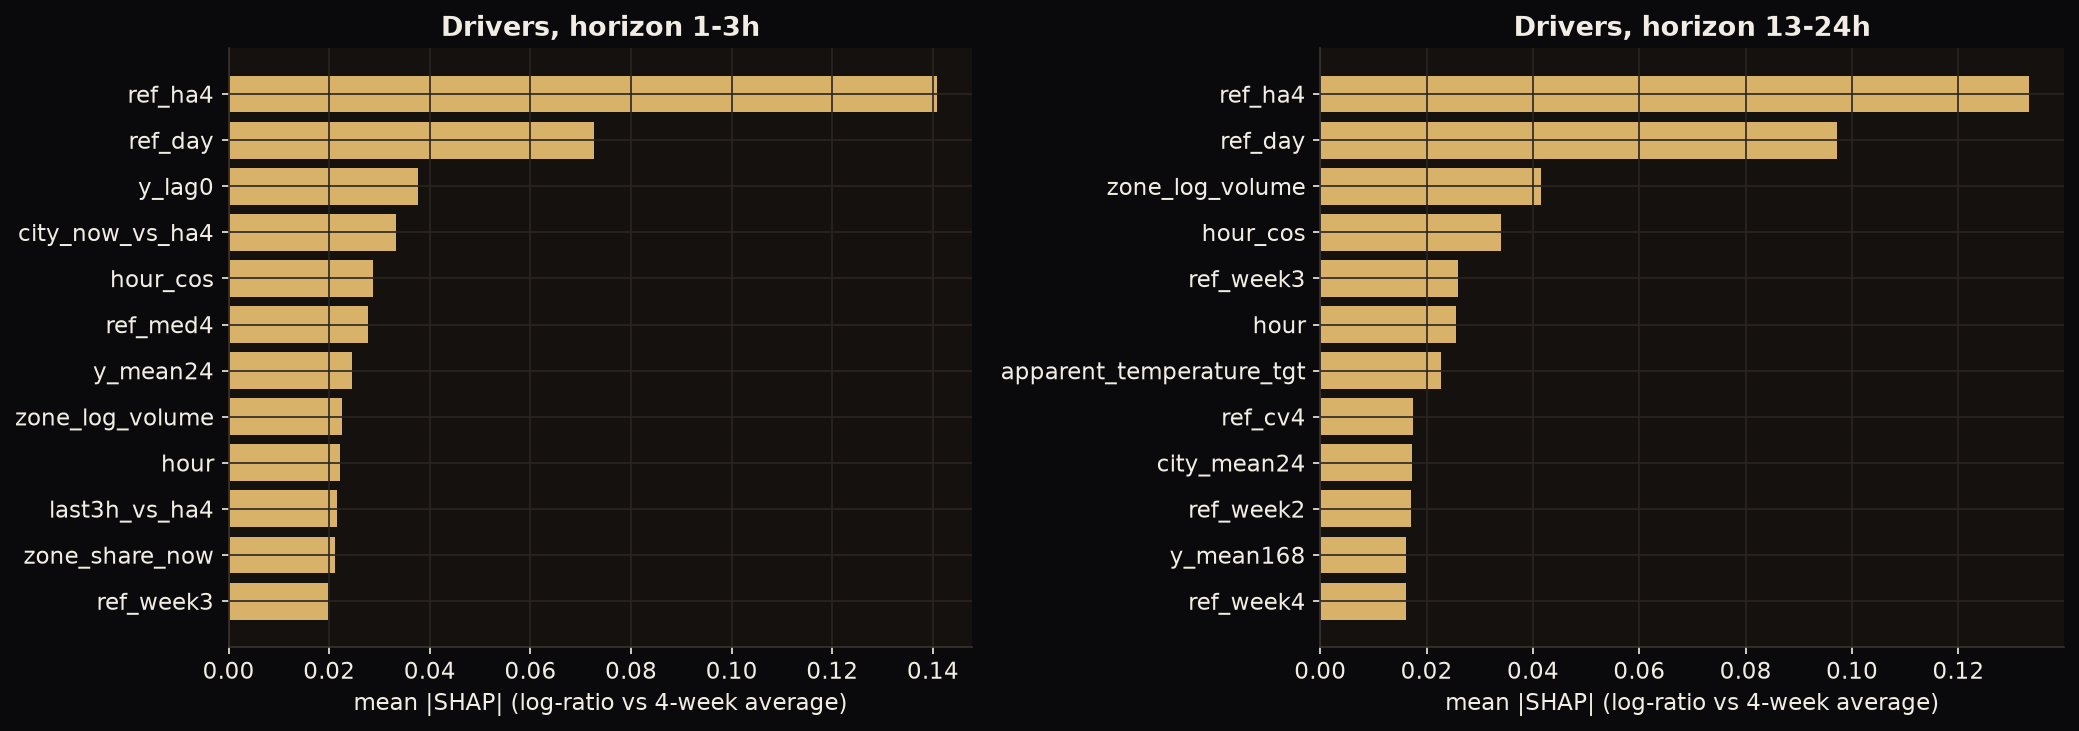

In [10]:
Image(str(C.FIGURES_DIR / "05_shap.png"))

Both horizon groups lean on the 4-week and same-hour-yesterday references and the city-wide 'busier than usual' ratio; weather features appear at longer horizons (apparent temperature) but individually carry little weight in a summer test month.

### Limitations
* Weather at the target hour is *observed* in training (a forecast in production): accuracy in storms will be worse than reported.
* Seven months of data: one winter, spring, and early summer; no autumn, no New Year's Eve, no big events (concerts, marathons).
* Demand = yellow-taxi pickups, not total ride-hailing demand or unmet demand.